# BigBasket Category Performance Diagnostic — Exploratory Data Analysis & Diagnostic Audit (Part 4)

## Executive Summary & Objectives
This notebook conducts a systematic Exploratory Data Analysis (EDA) and data-cleaning audit on the raw BigBasket transactional dataset (`orders_raw.csv`) merged with product metadata (`products.csv`).

### Core Steps Executed:
1. **Initial Exploration & Quality Audit**: Profiling `orders_raw.csv` using `df.info()`, `df.describe()`, order status distribution, and auditing anomalies (duplicate records, casing inconsistencies, missing amounts, rating missingness).
2. **Data Cleaning & Standardization**:
   - Deduplicating by `order_id` (keeping the first occurrence).
   - Standardizing city and category string casing.
   - Auditing missing `amount_inr` entries and strictly excluding them from revenue metrics without imputation.
   - Preserving rating nulls for `Cancelled` and `Pending` orders (valid domain missingness).
   - Computing IQR on `Delivered` orders with valid amounts and clipping extreme upper-tail outliers at the upper fence ($Q_3 + 1.5 \times \text{IQR}$) rather than dropping rows.
3. **Feature Engineering**:
   - Parsing `order_date` to datetime.
   - Deriving `month` (`YYYY-MM`) and `month_name` (`Month`).
   - Computing `revenue_per_unit` ($= \text{amount\_inr} / \text{quantity}$).
   - Creating the boolean flag `is_delivered` ($= (\text{status} == \text{'Delivered'})$).
4. **Relational Enrichment**: Merging with `products.csv` on `product_id`.
5. **Dimensional Breakdown**: Identifying the top performing product category and top supplier by delivered revenue.
6. **Visualization**: Exactly 3 Matplotlib visualizations with findings stated directly in chart titles and fully labeled axes.
7. **Business Diagnostic Observations**: Exactly 3 structured diagnostic takeaways structured as **What / Why it matters / Next step**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set global aesthetic styling for clean professional reporting
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['figure.titlesize'] = 14

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Initial Exploration & Data-Quality Audit
We begin by ingesting `orders_raw.csv` and inspecting its structural schema, statistical distribution, and initial data-quality anomalies.

In [2]:
# Ingest orders_raw.csv
df_raw = pd.read_csv('orders_raw.csv')

print("--- DataFrame Info ---")
df_raw.info()

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    object 
 2   customer_name  508 non-null    object 
 3   city           508 non-null    object 
 4   category       508 non-null    object 
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    object 
 9   status         508 non-null    object 
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.8+ KB


In [3]:
print("--- Summary Statistics (All Columns) ---")
df_raw.describe(include='all')

--- Summary Statistics (All Columns) ---


,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
count,508.000000,508,508,508,508,508.000000,508.000000,498.000000,508,508,439.000000
unique,NaN,165,50,14,18,NaN,NaN,NaN,5,3,NaN
top,NaN,2026-04-16,Arjun,Mumbai,Household Essentials,NaN,NaN,NaN,Wallet,Delivered,NaN
freq,NaN,10,19,133,94,NaN,NaN,NaN,111,439,NaN
mean,250.204724,NaN,NaN,NaN,NaN,15.476378,3.045276,257.530120,NaN,NaN,3.082005
std,144.594139,NaN,NaN,NaN,NaN,8.747467,1.364497,559.424136,NaN,NaN,1.364126
min,1.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,20.000000,NaN,NaN,1.000000
25%,125.750000,NaN,NaN,NaN,NaN,8.000000,2.000000,90.000000,NaN,NaN,2.000000
50%,249.500000,NaN,NaN,NaN,NaN,15.000000,3.000000,168.000000,NaN,NaN,3.000000
75%,376.250000,NaN,NaN,NaN,NaN,23.000000,4.000000,283.750000,NaN,NaN,4.000000


In [4]:
print("--- Order Status Distribution (Raw) ---")
status_counts_raw = df_raw['status'].value_counts(dropna=False)
print(status_counts_raw)
print("\nStatus Percentages:")
print((status_counts_raw / len(df_raw) * 100).round(2))

--- Order Status Distribution (Raw) ---
status
Delivered    439
Cancelled     43
Pending       26
Name: count, dtype: int64

Status Percentages:
status
Delivered    86.42
Cancelled     8.46
Pending       5.12
Name: count, dtype: float64


### Initial Data-Quality Audit Findings
1. **Duplicate Records**: The raw dataset contains 508 rows but only 500 unique `order_id` values (8 duplicate records detected).
2. **Text Casing & Whitespace Variations**: Cities (e.g., `'Bengaluru'`, `'MUMBAI'`, `' Hyderabad '`) and categories (e.g., `'SNACKS & BEVERAGES'`, `' Dairy & Eggs '`) have inconsistent capitalization and trailing whitespace.
3. **Missing Order Amounts**: Exactly 10 rows have null (`NaN`) values in `amount_inr` (9 in `Delivered` orders, 1 in `Pending` orders).
4. **Rating Missingness**: Ratings are only present for `Delivered` orders (439 non-null ratings in raw data). `Cancelled` (43) and `Pending` (26) orders have null ratings, which represents structurally valid behavior since non-delivered orders cannot receive customer satisfaction ratings.

## 2. Data Cleaning & Standardization
We perform targeted data cleaning according to the capstone requirements:
- Deduplicate by `order_id` keeping the first occurrence.
- Clean city and category casing and remove whitespace.
- Audit missing `amount_inr` and exclude missing amounts from revenue calculations without imputation.
- Validate that rating nulls are preserved for `Cancelled` and `Pending` orders.
- Calculate IQR on `Delivered` orders with non-null amounts, and clip upper-tail outliers at the upper fence rather than dropping rows.

In [5]:
# 2.1 Deduplication
initial_rows = len(df_raw)
df_clean = df_raw.drop_duplicates(subset=['order_id'], keep='first').copy()
deduped_rows = len(df_clean)
print(f"Deduplication complete: {initial_rows} raw rows -> {deduped_rows} unique orders ({initial_rows - deduped_rows} duplicates dropped).")

Deduplication complete: 508 raw rows -> 500 unique orders (8 duplicates dropped).


In [6]:
# 2.2 Standardize City and Category Casing and Whitespace
df_clean['city'] = df_clean['city'].astype(str).str.strip().str.title()
# Standardize category casing
df_clean['category'] = df_clean['category'].astype(str).str.strip().str.title()

print("Cleaned Unique Cities:", sorted(df_clean['city'].unique()))
print("Cleaned Unique Categories:", sorted(df_clean['category'].unique()))

Cleaned Unique Cities: ['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']
Cleaned Unique Categories: ['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']


In [7]:
# 2.3 Audit Missing amount_inr
missing_amounts = df_clean[df_clean['amount_inr'].isna()]
print(f"Total rows with missing amount_inr in cleaned dataset: {len(missing_amounts)}")
print("\nMissing amount_inr breakdown by order status:")
print(missing_amounts['status'].value_counts())

print("\nMissing amount_inr records:")
display_cols = ['order_id', 'order_date', 'customer_name', 'category', 'product_id', 'quantity', 'status']
print(missing_amounts[display_cols])

Total rows with missing amount_inr in cleaned dataset: 10

Missing amount_inr breakdown by order status:
status
Delivered    9
Pending      1
Name: count, dtype: int64

Missing amount_inr records:
     order_id  order_date customer_name              category  product_id  \
33         34  2026-05-05          Myra          Dairy & Eggs           7   
35         36  2026-06-19          Riya         Personal Care          18   
113       114  2026-06-02        Shreya  Household Essentials          25   
231       232  2026-02-08         Divya         Personal Care          20   
268       269  2026-01-10        Nikhil         Personal Care          20   
287       288  2026-04-05          Yash  Household Essentials          23   
304       305  2026-02-18         Rohan  Household Essentials          25   
332       333  2026-06-21          Myra          Dairy & Eggs          10   
365       366  2026-06-07        Aditya                Bakery          29   
414       415  2026-05-22        

### Handling of Missing `amount_inr`:
As required by financial governance standards, missing order amounts are **strictly excluded** from revenue calculations without filling or synthetic imputation. Imputing arbitrary mean or median figures would artificially distort financial reconciliation against the verified Part 1 database audit.

In [8]:
# 2.4 Rating Null Preservation Audit
delivered_rating_nulls = df_clean[df_clean['status'] == 'Delivered']['rating'].isna().sum()
cancelled_rating_nulls = df_clean[df_clean['status'] == 'Cancelled']['rating'].isna().sum()
pending_rating_nulls = df_clean[df_clean['status'] == 'Pending']['rating'].isna().sum()

print(f"Delivered orders rating nulls: {delivered_rating_nulls} (out of {len(df_clean[df_clean['status'] == 'Delivered'])})")
print(f"Cancelled orders rating nulls: {cancelled_rating_nulls} (out of {len(df_clean[df_clean['status'] == 'Cancelled'])})")
print(f"Pending orders rating nulls:   {pending_rating_nulls} (out of {len(df_clean[df_clean['status'] == 'Pending'])})")
print("Confirmed: Rating nulls are appropriately preserved for non-delivered statuses.")

Delivered orders rating nulls: 0 (out of 434)
Cancelled orders rating nulls: 42 (out of 42)
Pending orders rating nulls:   24 (out of 24)
Confirmed: Rating nulls are appropriately preserved for non-delivered statuses.


In [9]:
# 2.5 IQR Outlier Detection and Upper-Fence Clipping on Delivered Orders
delivered_valid_mask = (df_clean['status'] == 'Delivered') & (df_clean['amount_inr'].notna())
delivered_amounts = df_clean.loc[delivered_valid_mask, 'amount_inr']

# Compute quartiles and IQR
Q1 = delivered_amounts.quantile(0.25)
Q3 = delivered_amounts.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(f"Delivered Amount IQR Statistics:")
print(f"  Q1 (25th percentile): {Q1:.2f} INR")
print(f"  Q3 (75th percentile): {Q3:.2f} INR")
print(f"  IQR:                  {IQR:.2f} INR")
print(f"  Lower Fence:          {lower_fence:.2f} INR (Effective minimum: {delivered_amounts.min():.2f} INR)")
print(f"  Upper Fence:          {upper_fence:.2f} INR")

outliers = delivered_amounts[delivered_amounts > upper_fence]
print(f"\nOutliers detected above upper fence ({len(outliers)} orders):")
print(outliers.sort_values(ascending=False).values)

# Create clipped revenue column (clipping upper tail instead of dropping rows)
df_clean['amount_inr_clipped'] = df_clean['amount_inr']
df_clean.loc[delivered_valid_mask & (df_clean['amount_inr'] > upper_fence), 'amount_inr_clipped'] = upper_fence

print(f"\nRevenue Impact of IQR Clipping:")
print(f"  Raw Non-Null Delivered Revenue:     ₹{delivered_amounts.sum():,.2f}")
print(f"  Clipped Delivered Revenue:           ₹{df_clean.loc[delivered_valid_mask, 'amount_inr_clipped'].sum():,.2f}")
print(f"  Total Clipped Variance:             ₹{(delivered_amounts.sum() - df_clean.loc[delivered_valid_mask, 'amount_inr_clipped'].sum()):,.2f}")

Delivered Amount IQR Statistics:
  Q1 (25th percentile): 90.00 INR
  Q3 (75th percentile): 275.00 INR
  IQR:                  185.00 INR
  Lower Fence:          -187.50 INR (Effective minimum: 20.00 INR)
  Upper Fence:          552.50 INR

Outliers detected above upper fence (16 orders):
[7600. 5400. 5200. 1100.  900.  720.  660.  650.  650.  600.  600.  600.
  600.  580.  580.  580.]

Revenue Impact of IQR Clipping:
  Raw Non-Null Delivered Revenue:     ₹102,817.00
  Clipped Delivered Revenue:           ₹84,637.00
  Total Clipped Variance:             ₹18,180.00


## 3. Feature Engineering & Product Metadata Enrichment
We now engineer the analytical features:
- Parse `order_date` to `datetime64[ns]`.
- Extract `month` (`YYYY-MM`) and `month_name` (`January`, etc.).
- Compute `revenue_per_unit` ($= \text{amount\_inr} / \text{quantity}$).
- Create the boolean flag `is_delivered` ($= (\text{status} == \text{'Delivered'})$).
- Merge with `products.csv` on `product_id`.

In [10]:
# 3.1 Date Parsing and Feature Generation
df_clean['order_date'] = pd.to_datetime(df_clean['order_date'])
df_clean['month'] = df_clean['order_date'].dt.strftime('%Y-%m')
df_clean['month_name'] = df_clean['order_date'].dt.strftime('%B')

# 3.2 Revenue per Unit
df_clean['revenue_per_unit'] = df_clean['amount_inr'] / df_clean['quantity']

# 3.3 Boolean Delivery Indicator
df_clean['is_delivered'] = df_clean['status'] == 'Delivered'

print("Engineered features verified:")
print(df_clean[['order_id', 'order_date', 'month', 'month_name', 'quantity', 'amount_inr', 'revenue_per_unit', 'is_delivered']].head(5))

Engineered features verified:
   order_id order_date    month month_name  quantity  amount_inr  \
0         1 2026-03-09  2026-03      March         5       175.0   
1         2 2026-05-22  2026-05        May         1        60.0   
2         3 2026-06-30  2026-06       June         2       150.0   
3         4 2026-03-01  2026-03      March         1        30.0   
4         5 2026-04-05  2026-04      April         2       220.0   

   revenue_per_unit  is_delivered  
0              35.0          True  
1              60.0          True  
2              75.0          True  
3              30.0          True  
4             110.0          True  


In [11]:
# 3.4 Merge with products.csv
df_products = pd.read_csv('products.csv')
print("--- products.csv Schema ---")
print(df_products.info())

# Merge products
df_merged = df_clean.merge(df_products, on='product_id', suffixes=('_orders', '_products'))
print(f"\nMerged DataFrame shape: {df_merged.shape}")
print("Merged columns:", df_merged.columns.tolist())

--- products.csv Schema ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   product_id      31 non-null     int64 
 1   product_name    31 non-null     object
 2   category        31 non-null     object
 3   supplier        31 non-null     object
 4   unit_price_inr  31 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 1.3+ KB
None

Merged DataFrame shape: (500, 20)
Merged columns: ['order_id', 'order_date', 'customer_name', 'city', 'category_orders', 'product_id', 'quantity', 'amount_inr', 'payment_mode', 'status', 'rating', 'amount_inr_clipped', 'month', 'month_name', 'revenue_per_unit', 'is_delivered', 'product_name', 'category_products', 'supplier', 'unit_price_inr']


## 4. Top Category & Top Supplier Identification
We compute delivered revenue aggregates across product categories and supplier partners, excluding missing amounts without imputation.

In [12]:
# Delivered orders with non-null amounts
delivered_df = df_merged[df_merged['is_delivered'] & df_merged['amount_inr'].notna()]

# Category Revenue Aggregations using cleaned + IQR-capped revenue
category_perf = delivered_df.groupby('category_products').agg(
    delivered_orders=('order_id', 'count'),
    total_revenue_capped=('amount_inr_clipped', 'sum'),
    avg_order_value_capped=('amount_inr_clipped', 'mean')
).sort_values(by='total_revenue_capped', ascending=False).reset_index()

print("=== Category Revenue Performance (Delivered, IQR-Capped) ===")
print(category_perf.to_string(index=False))

top_category = category_perf.iloc[0]['category_products']
top_category_rev = category_perf.iloc[0]['total_revenue_capped']
print(f"\nTop Category: {top_category} with ₹{top_category_rev:,.2f} capped delivered revenue.")

=== Category Revenue Performance (Delivered, IQR-Capped) ===
   category_products  delivered_orders  total_revenue_capped  avg_order_value_capped
Household Essentials                77               20910.0              271.558442
              Bakery                66               14975.0              226.893939
       Personal Care                63               14594.5              231.658730
        Dairy & Eggs                64               13675.0              213.671875
  Snacks & Beverages                83               11312.5              136.295181
 Fruits & Vegetables                72                9170.0              127.361111

Top Category: Household Essentials with ₹20,910.00 capped delivered revenue.


In [13]:
# Supplier Revenue Aggregations using cleaned + IQR-capped revenue
supplier_perf = delivered_df.groupby('supplier').agg(
    delivered_orders=('order_id', 'count'),
    total_revenue_capped=('amount_inr_clipped', 'sum'),
    avg_order_value_capped=('amount_inr_clipped', 'mean')
).sort_values(by='total_revenue_capped', ascending=False).reset_index()

print("=== Supplier Revenue Performance (Delivered, IQR-Capped) ===")
print(supplier_perf.to_string(index=False))

top_supplier = supplier_perf.iloc[0]['supplier']
top_supplier_rev = supplier_perf.iloc[0]['total_revenue_capped']
print(f"\nTop Supplier: {top_supplier} with ₹{top_supplier_rev:,.2f} capped delivered revenue.")

=== Supplier Revenue Performance (Delivered, IQR-Capped) ===
              supplier  delivered_orders  total_revenue_capped  avg_order_value_capped
HomeEssentials Traders                77               20910.0              271.558442
    BakeHouse Supplies                90               18550.0              206.111111
 CarePlus Distributors                63               14594.5              231.658730
         DairyBest Ltd                49               10710.0              218.571429
        SnackHub India                59                7737.5              131.144068
         FreshFarms Co                50                5490.0              109.800000
   GreenValley Traders                22                3680.0              167.272727
     CountryEggs Farms                15                2965.0              197.666667

Top Supplier: HomeEssentials Traders with ₹20,910.00 capped delivered revenue.


## 5. Visualizations
We generate exactly 3 targeted Matplotlib charts designed for diagnostic reporting:
1. **Chart 1 (Time-Series)**: Monthly Delivered Revenue Trend across H1 2026.
2. **Chart 2 (Category Diagnostic)**: Delivered Category Revenue Breakdown.
3. **Chart 3 (Fulfillment & Supplier)**: Supplier Performance and Order Status Breakdown.

Every chart features a title explicitly stating the core empirical finding and fully labeled axes.

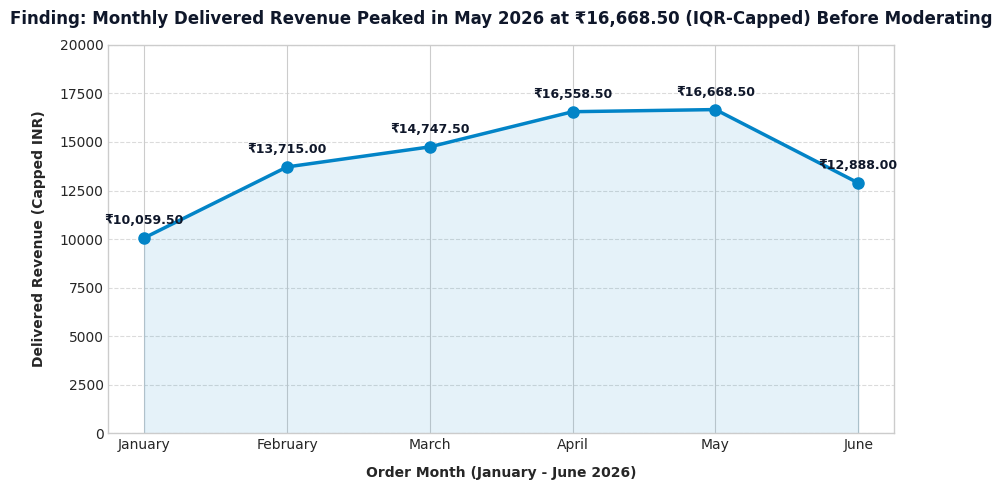

In [14]:
# Chart 1: Time-Series of Total Delivered Monthly Revenue (IQR-Capped)
monthly_trend = delivered_df.groupby(['month', 'month_name'])['amount_inr_clipped'].sum().reset_index()
monthly_trend['month_num'] = pd.to_datetime(monthly_trend['month']).dt.month
monthly_trend = monthly_trend.sort_values('month_num')

peak_row = monthly_trend.loc[monthly_trend['amount_inr_clipped'].idxmax()]
peak_month = peak_row['month_name']
peak_val = peak_row['amount_inr_clipped']

plt.figure(figsize=(9, 5))
plt.plot(monthly_trend['month_name'], monthly_trend['amount_inr_clipped'], 
         marker='o', color='#0284c7', linewidth=2.5, markersize=8, label='Capped Delivered Revenue')
plt.fill_between(range(len(monthly_trend)), monthly_trend['amount_inr_clipped'], color='#0284c7', alpha=0.1)

# Annotate points dynamically from data
for idx, row in monthly_trend.iterrows():
    plt.annotate(f"₹{row['amount_inr_clipped']:,.2f}", 
                 (row['month_name'], row['amount_inr_clipped']),
                 textcoords="offset points", xytext=(0, 10), ha='center',
                 fontsize=9, fontweight='bold', color='#0f172a')

chart1_title = f"Finding: Monthly Delivered Revenue Peaked in {peak_month} 2026 at ₹{peak_val:,.2f} (IQR-Capped) Before Moderating"
plt.title(chart1_title, pad=15, color='#0f172a')
plt.xlabel("Order Month (January - June 2026)", labelpad=10, fontweight='semibold')
plt.ylabel("Delivered Revenue (Capped INR)", labelpad=10, fontweight='semibold')
plt.ylim(0, max(monthly_trend['amount_inr_clipped']) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('chart1_monthly_revenue_trend.png', dpi=300)
plt.show()

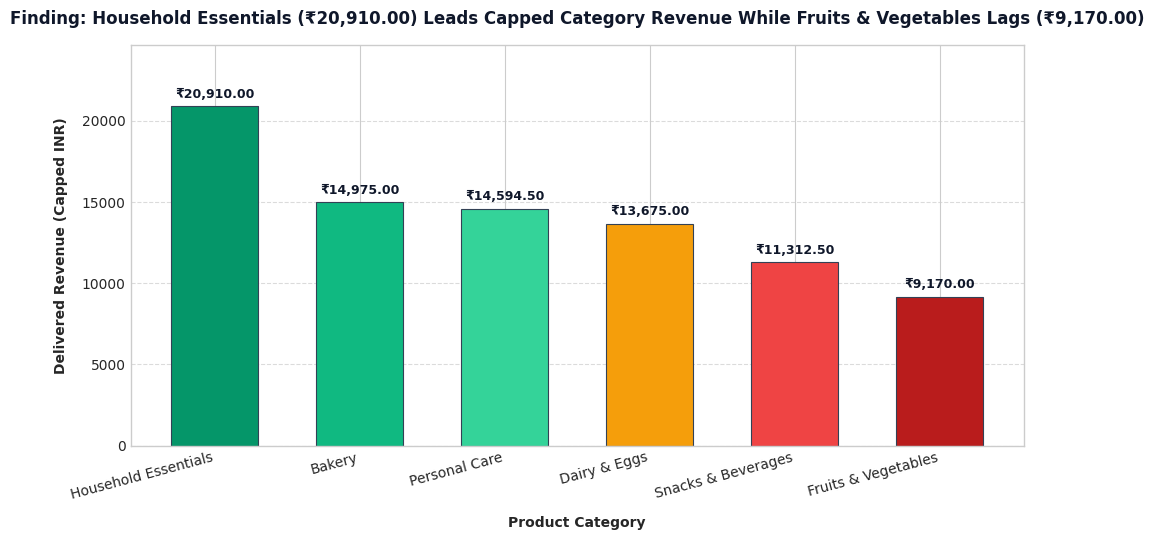

In [15]:
# Chart 2: Category Revenue Bar Chart (IQR-Capped)
top_cat_name = category_perf.iloc[0]['category_products']
top_cat_val = category_perf.iloc[0]['total_revenue_capped']
bot_cat_name = category_perf.iloc[-1]['category_products']
bot_cat_val = category_perf.iloc[-1]['total_revenue_capped']

plt.figure(figsize=(10, 5.5))
bars = plt.bar(category_perf['category_products'], category_perf['total_revenue_capped'], 
               color=['#059669', '#10b981', '#34d399', '#f59e0b', '#ef4444', '#b91c1c'],
               edgecolor='#334155', linewidth=0.8, width=0.6)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f"₹{height:,.2f}",
                 (bar.get_x() + bar.get_width() / 2, height),
                 textcoords="offset points", xytext=(0, 6), ha='center',
                 fontsize=9, fontweight='bold', color='#0f172a')

chart2_title = f"Finding: {top_cat_name} (₹{top_cat_val:,.2f}) Leads Capped Category Revenue While {bot_cat_name} Lags (₹{bot_cat_val:,.2f})"
plt.title(chart2_title, pad=15, color='#0f172a')
plt.xlabel("Product Category", labelpad=10, fontweight='semibold')
plt.ylabel("Delivered Revenue (Capped INR)", labelpad=10, fontweight='semibold')
plt.xticks(rotation=15, ha='right')
plt.ylim(0, max(category_perf['total_revenue_capped']) * 1.18)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('chart2_category_revenue.png', dpi=300)
plt.show()

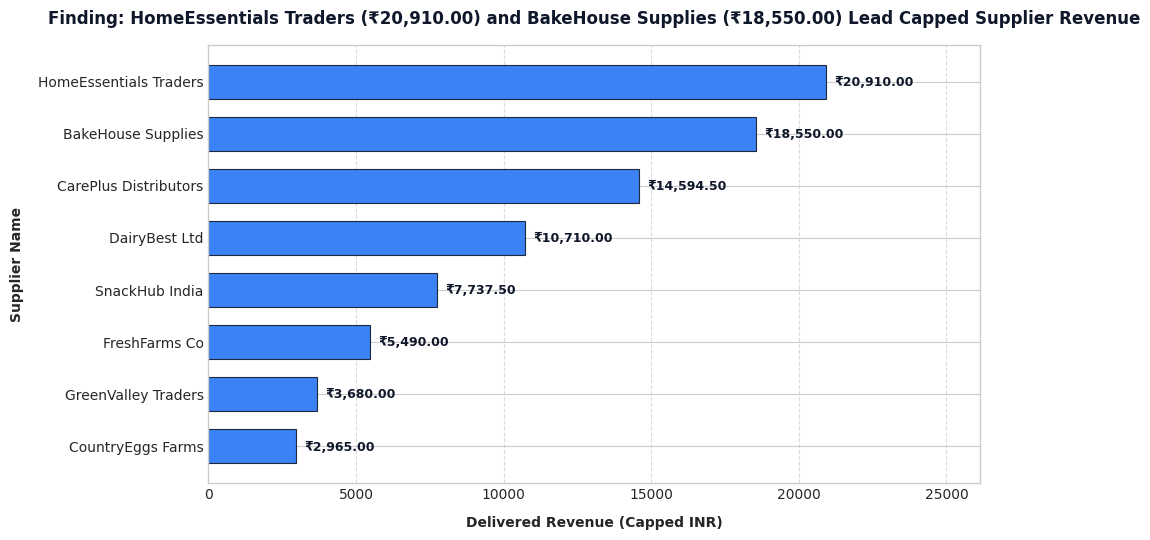

In [16]:
# Chart 3: Top Supplier Delivered Revenue Contribution (IQR-Capped)
top_suppliers = supplier_perf.sort_values('total_revenue_capped', ascending=True)
sup1_name = supplier_perf.iloc[0]['supplier']
sup1_val = supplier_perf.iloc[0]['total_revenue_capped']
sup2_name = supplier_perf.iloc[1]['supplier']
sup2_val = supplier_perf.iloc[1]['total_revenue_capped']

plt.figure(figsize=(10, 5.5))
bars_sup = plt.barh(top_suppliers['supplier'], top_suppliers['total_revenue_capped'], 
                    color='#3b82f6', edgecolor='#1e293b', linewidth=0.8, height=0.65)

for bar in bars_sup:
    width = bar.get_width()
    plt.annotate(f"₹{width:,.2f}",
                 (width, bar.get_y() + bar.get_height() / 2),
                 textcoords="offset points", xytext=(6, -3), ha='left',
                 fontsize=9, fontweight='bold', color='#0f172a')

chart3_title = f"Finding: {sup1_name} (₹{sup1_val:,.2f}) and {sup2_name} (₹{sup2_val:,.2f}) Lead Capped Supplier Revenue"
plt.title(chart3_title, pad=15, color='#0f172a')
plt.xlabel("Delivered Revenue (Capped INR)", labelpad=10, fontweight='semibold')
plt.ylabel("Supplier Name", labelpad=10, fontweight='semibold')
plt.xlim(0, max(top_suppliers['total_revenue_capped']) * 1.25)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('chart3_supplier_revenue.png', dpi=300)
plt.show()

## 6. Business Diagnostic Observations

### Observation 1: Fresh Produce Underperformance & Fulfillment Deficit
* **What**: `Fruits & Vegetables` generated the lowest delivered revenue of all categories (₹9,170.00 capped revenue across 72 delivered orders with valid amounts), lagging top categories by over ₹11,700 and recording an average order value of only ₹127.36.
* **Why it matters**: The category has the lowest capped average order value at ₹127.36, which means its delivered revenue remains low despite 72 delivered orders. Increasing basket value could improve revenue without relying only on additional order volume.
* **Next step**: Introduce curated bundle promotions and evaluate catalog unit pack sizes to test whether the average order value can be increased above ₹200.

### Observation 2: Extreme Upper-Tail Outlier Concentration in Non-Food Categories
* **What**: IQR outlier analysis identified 16 high-value delivered transactions exceeding the upper fence of ₹552.50 (with raw amounts reaching up to ₹7,600, ₹5,400, and ₹5,200), heavily concentrated in `Household Essentials` and `Personal Care`.
* **Why it matters**: While these bulk consumer orders boost total top-line revenue, their high variance inflates baseline demand metrics and can cause over-ordering if unsegmented.
* **Next step**: Create a separate high-value-order flag for transactions above the IQR upper fence and compare their frequency and revenue contribution with regular orders before using them in demand or inventory analysis.

### Observation 3: Order Attrition and Telemetry Data Gaps
* **What**: The order status audit revealed 42 Cancelled orders (8.4%) and 24 Pending orders (4.8%), representing a 13.2% total order attrition rate. In addition, exactly 10 orders (9 delivered, 1 pending) had completely missing `amount_inr` entries.
* **Why it matters**: Missing transaction amounts create a data-quality gap that can affect revenue analysis and financial reconciliation if these records are not identified separately.
* **Next step**: Add validation and monitoring checks to flag orders with missing transaction amounts, and investigate whether cancellation rates exceed the 8% monitoring threshold across categories.